# Modelamiento: técnicas de Machine Learning

Este notebook entrena y evalúa las tres técnicas de ML seleccionadas para el proyecto —
regresión logística, Random Forest y XGBoost— sobre el conjunto de entrenamiento
preprocesado, usando pesos de clase como estrategia inicial de balanceo (la misma
calculada en `02_preprocesamiento.ipynb`).

La comparación de estrategias de balanceo (pesos vs. RandomOverSampler vs. SMOTE) sobre
estos mismos modelos se realiza en `04_balanceo_modelos.ipynb`. La comparación final con
las arquitecturas de deep learning y la evaluación en el conjunto de prueba se realizan en
`05_modelamiento_dl.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Carga de artefactos preprocesados

Se cargan el preprocesador ajustado y los conjuntos ya transformados, generados en `02_preprocesamiento.ipynb`.

In [2]:
ruta_artefactos = Path("../artifacts")

artefactos = joblib.load(ruta_artefactos / "splits_preprocesados.joblib")

X_train = artefactos["X_train"]
X_val = artefactos["X_val"]
X_test = artefactos["X_test"]
y_train = artefactos["y_train"]
y_val = artefactos["y_val"]
y_test = artefactos["y_test"]
pesos_clase = artefactos["pesos_clase"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("Pesos de clase:", pesos_clase)

X_train: (7000, 58)
X_val: (1500, 58)
X_test: (1500, 58)
Pesos de clase: {0: 0.5568814638027049, 1: 4.895104895104895}


## 2. Función de evaluación común

Se define una función que calcula el conjunto de métricas usado en todo el informe
(accuracy, precision, recall, F1, ROC-AUC, PR-AUC) y la matriz de confusión, para
aplicarla de forma consistente a los tres modelos.

In [3]:
def evaluar_modelo(nombre, modelo, X, y_true):
    y_pred = modelo.predict(X)
    y_proba = modelo.predict_proba(X)[:, 1]

    metricas = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

    matriz = confusion_matrix(y_true, y_pred)

    return metricas, matriz


resultados_validacion = []
matrices_validacion = {}

## 3. Regresión logística + pesos de clase

Modelo base interpretable. Se usa `class_weight` con los pesos calculados en el
preprocesamiento y un máximo de 2.000 iteraciones, tal como se documentó en el informe.

In [4]:
modelo_lr = LogisticRegression(
    max_iter=2000,
    class_weight=pesos_clase,
    random_state=RANDOM_STATE,
)

modelo_lr.fit(X_train, y_train)

metricas_lr, matriz_lr = evaluar_modelo("Regresión logística + pesos", modelo_lr, X_val, y_val)
resultados_validacion.append(metricas_lr)
matrices_validacion["Regresión logística + pesos"] = matriz_lr

metricas_lr

{'modelo': 'Regresión logística + pesos',
 'accuracy': 0.7,
 'precision': 0.20710059171597633,
 'recall': 0.6862745098039216,
 'f1': 0.3181818181818182,
 'roc_auc': 0.750095831453096,
 'pr_auc': 0.22352564749065099}

## 4. Random Forest (pesos de clase)

Ensamble de árboles con 250 estimadores, profundidad máxima 8, mínimo de 4 observaciones
por hoja y `class_weight="balanced_subsample"`, según lo documentado en el informe.

In [5]:
modelo_rf = RandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    min_samples_leaf=4,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

modelo_rf.fit(X_train, y_train)

metricas_rf, matriz_rf = evaluar_modelo("Random Forest (pesos de clase)", modelo_rf, X_val, y_val)
resultados_validacion.append(metricas_rf)
matrices_validacion["Random Forest (pesos de clase)"] = matriz_rf

metricas_rf

{'modelo': 'Random Forest (pesos de clase)',
 'accuracy': 0.8173333333333334,
 'precision': 0.3042071197411003,
 'recall': 0.6143790849673203,
 'f1': 0.4069264069264069,
 'roc_auc': 0.8199047993362155,
 'pr_auc': 0.3124297250768069}

## 5. XGBoost (pesos de clase)

Gradient boosting con 120 estimadores, profundidad 3, learning rate 0,05, subsample y
colsample_bytree en 0,8, y `scale_pos_weight` igual a la relación de clases del
entrenamiento (permanece / abandona).

In [6]:
relacion_desbalance = (y_train == 0).sum() / (y_train == 1).sum()

modelo_xgb = XGBClassifier(
    n_estimators=120,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=relacion_desbalance,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=-1,
)

modelo_xgb.fit(X_train, y_train)

metricas_xgb, matriz_xgb = evaluar_modelo("XGBoost (pesos de clase)", modelo_xgb, X_val, y_val)
resultados_validacion.append(metricas_xgb)
matrices_validacion["XGBoost (pesos de clase)"] = matriz_xgb

metricas_xgb

{'modelo': 'XGBoost (pesos de clase)',
 'accuracy': 0.7306666666666667,
 'precision': 0.24849699398797595,
 'recall': 0.8104575163398693,
 'f1': 0.3803680981595092,
 'roc_auc': 0.8187499696735908,
 'pr_auc': 0.32920925364669734}

## 6. Comparación de los tres modelos en validación

In [7]:
tabla_resultados = pd.DataFrame(resultados_validacion).set_index("modelo").round(3)
tabla_resultados

,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,
Regresión logística + pesos,0.700,0.207,0.686,0.318,0.750,0.224
Random Forest (pesos de clase),0.817,0.304,0.614,0.407,0.820,0.312
XGBoost (pesos de clase),0.731,0.248,0.810,0.380,0.819,0.329


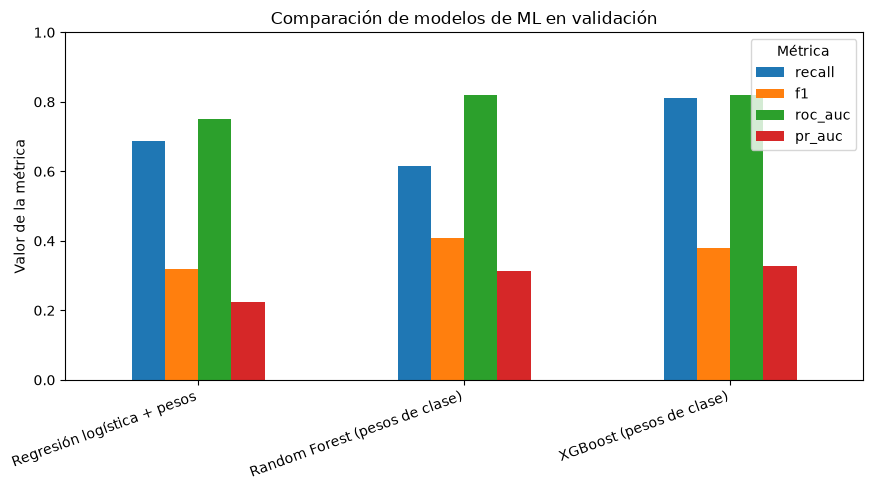

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

metricas_a_graficar = ["recall", "f1", "roc_auc", "pr_auc"]
tabla_resultados[metricas_a_graficar].plot(kind="bar", ax=ax)

ax.set_title("Comparación de modelos de ML en validación")
ax.set_ylabel("Valor de la métrica")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.legend(title="Métrica", loc="upper right")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

ruta_figuras = Path("../figures")
ruta_figuras.mkdir(exist_ok=True)
plt.savefig(ruta_figuras / "08_01_comparacion_modelos_ml.png", dpi=150)
plt.show()

## 7. Matrices de confusión en validación

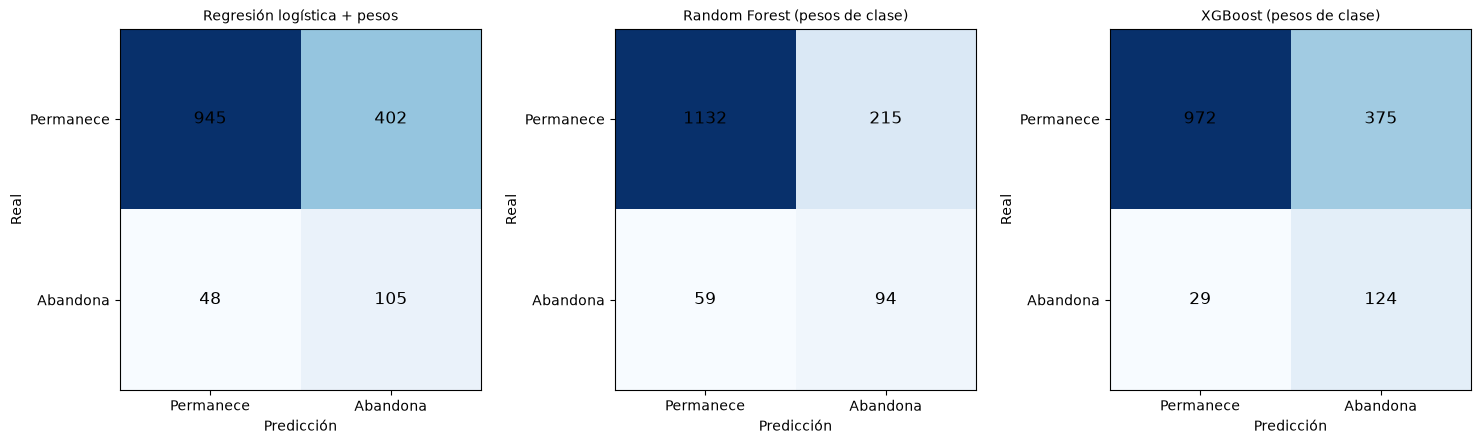

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (nombre, matriz) in zip(axes, matrices_validacion.items()):
    ax.imshow(matriz, cmap="Blues")
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Permanece", "Abandona"])
    ax.set_yticklabels(["Permanece", "Abandona"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, matriz[i, j], ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.savefig(ruta_figuras / "08_02_matrices_confusion_ml.png", dpi=150)
plt.show()

## 8. Guardado de modelos entrenados

Se guardan los tres modelos entrenados en `models/` para su uso posterior en el estudio
de balanceo (`04_balanceo_modelos.ipynb`) y en la comparación final con las arquitecturas
de deep learning (`05_modelamiento_dl.ipynb`).

In [10]:
ruta_modelos = Path("../models")
ruta_modelos.mkdir(exist_ok=True)

joblib.dump(modelo_lr, ruta_modelos / "logistic_regression_pesos.joblib")
joblib.dump(modelo_rf, ruta_modelos / "random_forest_balanceado.joblib")
joblib.dump(modelo_xgb, ruta_modelos / "xgboost_balanceado.joblib")

tabla_resultados.to_csv(ruta_modelos / "resultados_validacion_ml.csv")

print("Modelos y resultados guardados en:", ruta_modelos.resolve())

Modelos y resultados guardados en: C:\Users\Usuario\OneDrive\Documentos\UNAB\2026\Machine Learning\Proyecto\acif104-churn-grupo3\models


## 9. Conclusiones preliminares

Con una sola estrategia de balanceo (pesos de clase), Random Forest y XGBoost superan claramente a la regresión logística, y se observan diferencias relevantes entre ellos:

- **Random Forest (pesos de clase)** obtuvo el mejor F1 (0,407) y la mayor accuracy entre los modelos balanceados (0,817), con precision de 0,304.
- **XGBoost (pesos de clase)** obtuvo el mayor recall (0,810) y la mejor PR-AUC (0,329), detectando una proporción notablemente mayor de clientes que abandonan que Random Forest (recall 0,614). El ROC-AUC de ambos es casi idéntico (0,820 vs. 0,819), es decir, discriminan igual de bien de forma global, pero XGBoost lo hace priorizando la detección de la clase positiva.
- **Regresión logística + pesos** queda por debajo en F1 y PR-AUC, pero mantiene un recall razonable (0,686) y sigue siendo útil como referencia interpretable.

Dado que el objetivo de negocio prioriza recall (no detectar a un cliente que abandonará impide accionar la retención), XGBoost es hasta ahora el candidato más alineado con ese criterio, seguido de cerca por Random Forest si se prioriza el equilibrio precision-recall (F1).

Estas conclusiones son preliminares porque solo se probó una técnica de balanceo. El notebook `04_balanceo_modelos.ipynb` evalúa si `RandomOverSampler` o `SMOTE` mejoran estos resultados para Random Forest y XGBoost, y el notebook `05_modelamiento_dl.ipynb` incorpora las arquitecturas de deep learning y la evaluación final en el conjunto de prueba.